In [ ]:
import pandas as pd
import re
import unicodedata

# URL do Google Sheet
sheet_id = '1V-PBqzSPv5zA60feW-igXbojmYbHDXoFosqgn2FhSgc'
url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv'

# Ler os dados e armazenar em um DataFrame chamado dados
# Ajustando o cabeçalho para a segunda linha (índice 1)
dados = pd.read_csv(url, header=1)

# Função para limpar e simplificar nomes de colunas
def clean_col_name(col_name):
    # Normalizar caracteres unicode para remover acentos
    col_name = unicodedata.normalize('NFKD', col_name).encode('ascii', 'ignore').decode('utf-8')
    # Converter para minúsculas
    col_name = col_name.lower()
    # Substituir quebras de linha por um espaço
    col_name = col_name.replace('\n', ' ')
    # Remover conteúdo dentro de parênteses
    col_name = re.sub(r'\(.*?\)', '', col_name)
    # Remover pontos e vírgulas
    col_name = col_name.replace('.', '').replace(',', '')
    # Remover outros caracteres especiais que não sejam alfanuméricos ou espaços
    col_name = re.sub(r'[^\w\s]', '', col_name)
    # Substituir múltiplos espaços por um único underscore
    col_name = re.sub(r'\s+', '_', col_name)
    # Remover underscores iniciais/finais
    col_name = col_name.strip('_')
    return col_name

# Aplicar a função de limpeza a todos os nomes de colunas
dados.columns = [clean_col_name(col) for col in dados.columns]

# Remover a coluna 'responsavel_ctto_inicial_1' se ela existir
if 'responsavel_ctto_inicial_1' in dados.columns:
    dados = dados.drop(columns=['responsavel_ctto_inicial_1'])
#    print("Coluna 'responsavel_ctto_inicial_1' removida com sucesso.")

#print("Novos nomes das colunas:")
#print(dados.columns.tolist())

from IPython.display import display

#display(dados)

for col in dados.columns.tolist():
    print(col)

responsavel_ctto_inicial
vinculo_instituicao
autoridade_funcao
precedencia
participara_do_evento
participara_da_cerimonia_de_restituicao_dos_espadins
participara_do_culto_religioso
participara_da_entrega_de_premios
participara_da_colacao_de_grau
a_autoridade_almocara_no_foyer
efetivo_de_acomanhantes_para_o_almoco
nomes_dos_acompanhantes_para_o_almoco_no_foyer
integrantes_da_comitiva
previsao_de_chegada_em_resende
previsao_de_saida_de_resende
apoio_de_hospedagem_para_autoridade
nome_dos_integrantes_para_alojamento_da_comitiva
efetivo_da_comitiva_que_seja_alojado
carro_ou_viatura
abastecer_viatura_funcional
quantas_viaturas_irao_abastecer
restricao_alimentar_da_autoridade
origem_da_informacao
observacao
ultima_atualizacao_do_responsavel
oficial_de_ligacao
telefones


RELATÓRIO DE AUTORIDADES **CONFIRMADAS**


In [ ]:
import pandas as pd
from IPython.display import display

# Define the list of cleaned column names for display in the report
display_columns = [
    'autoridade_funcao',
    'previsao_de_chegada_em_resende',
    'integrantes_da_comitiva',
    'observacao',
    'oficial_de_ligacao',
    'telefones'
]

# Filter the 'dados' DataFrame to include only rows where 'participara_do_evento' is 'SIM'
filtered_dados = dados[dados['participara_do_evento'] == 'SIM']

# Sort the filtered DataFrame by 'precedencia' to maintain the desired order
# Use .copy() to avoid SettingWithCopyWarning later if modifications were to be made
filtered_dados = filtered_dados.sort_values(by='precedencia').copy()

# Create the report by selecting the specified columns from the sorted filtered DataFrame
relatorio_autoridades = filtered_dados[display_columns]

# Display the title
print("## RELATÓRIO DE AUTORIDADES CONFIRMADAS")

# Display the report
display(relatorio_autoridades)

# Print the total number of confirmed authorities
print(f"Total de autoridades confirmadas: {len(relatorio_autoridades)}")

## RELATÓRIO DE AUTORIDADES CONFIRMADAS


,autoridade_funcao,previsao_de_chegada_em_resende,integrantes_da_comitiva,observacao,oficial_de_ligacao,telefones
0,Sr General de Exército TOMÁS MIGUEL MINÉ RIBEI...,DD HH MM,yyyyyy,OBSERVAÇÃO,oficial X1,Tel (61) 3415-4382 / 5200 / 6980 / 4341 / 6519...
1,Sr General de Exército FRANCISCO HUMBERTO MONT...,DD HH MM,yyyyyy,OBSERVAÇÃO,oficial X2,Tel (61) 3415-4724 / 4109 / 6583 / 5028 / 5808...
2,Sr General de Exército RICARDO JOSÉ NIGRI - Ch...,DD HH MM,yyyyyy,OBSERVAÇÃO,oficial X7,Tel (21) 2519-5700 / 5160 / 5785 / 5009 / 5373...
3,Sr General de Exército JOSÉ RICARDO VENDRAMIN ...,DD HH MM,yyyyyy,OBSERVAÇÃO,oficial X8,Tel (91) 3211-3707 / 3701. RITEX 848
4,Sr General de Exército PEDRO CELSO COELHO MONT...,DD HH MM,yyyyyy,OBSERVAÇÃO,oficial X9,Tel (21) 2519-5253 / 5084. RITEX 810-5539 / 5254
5,Sr General de Exército RICARDO PIAI CARMONA - ...,DD HH MM,yyyyyy,OBSERVAÇÃO,oficial X10,Tel (11) 3278-4102 / 4103 / 4107. RITEX 820
6,Sr General de Exército KLEBER NUNES DE VASCONC...,DD HH MM,yyyyyy,OBSERVAÇÃO,oficial X11,Tel (61) 3415-6317 / 4121 / 4895. RITEX 860.
7,Sr General de Exército LUCIANO GUILHERME CABRA...,DD HH MM,yyyyyy,OBSERVAÇÃO,oficial X12,Tel (61) 2035-3104 / 3047 / 3008 / 3007 / 3101...
8,Sr General de Exército MARCELO ARANTES GUEDON ...,DD HH MM,yyyyyy,OBSERVAÇÃO,oficial X13,Tel (61) 3415-4239 / 6318 / 5001 / 5821 / 5021...
9,Sr General de Exército LUIZ FERNANDO ESTORILHO...,DD HH MM,yyyyyy,OBSERVAÇÃO,oficial X14,Tel (61) 3415- 4145 / 4146 / 4244 / 5050 / 576...


Total de autoridades confirmadas: 46


RELATÓRIO DE AUTORIDADES **NÃO CONTACTADAS**

In [ ]:
import pandas as pd
from IPython.display import display

# Define the list of cleaned column names for the new report
report_uncontacted_columns = [
    'precedencia',
    'autoridade_funcao',
    'responsavel_ctto_inicial',
    'observacao'
]

# Filter the 'dados' DataFrame to include only rows where 'participara_do_evento' is 'nao_contactado'
filtered_uncontacted_dados = dados[dados['participara_do_evento'] == 'NÃO CONTACTADO']

# Create the report by selecting the specified columns from the filtered DataFrame
relatorio_autoridades_nao_contactadas = filtered_uncontacted_dados[report_uncontacted_columns]

# Display the title
print("## RELATÓRIO DE AUTORIDADES NÃO CONTACTADAS")

# Display the report
display(relatorio_autoridades_nao_contactadas)

# Print the total number of non-contacted authorities
print(f"Total de autoridades não contactadas: {len(relatorio_autoridades_nao_contactadas)}")

## RELATÓRIO DE AUTORIDADES NÃO CONTACTADAS


,precedencia,autoridade_funcao,responsavel_ctto_inicial,observacao
46,6,Sr General de Divisão ANYSIO LUIZ CRESPO ALVES...,TC Pimentel,OBSERVAÇÃO
47,6,Sr General de Divisão EDUARDO TAVARES MARTINS ...,TC Pimentel,OBSERVAÇÃO
48,6,Sr General de Divisão Médico CESAR UILSON GOET...,TC Pimentel,OBSERVAÇÃO
49,6,Sr General de Divisão IVAN ALEXANDRE CORRÊA SI...,TC Pimentel,OBSERVAÇÃO
50,6,Sr General de Divisão ALESSANDRO DA SILVA - 4º...,TC Pimentel,OBSERVAÇÃO
...,...,...,...,...
318,999,Sra SHIRLEY LESSA PASINATO - Mãe Gen Pasinato,TC Reserva 3,OBSERVAÇÃO
319,999,Sr HUGO MARIVAL PASINATO - Pai Gen Pasinato,TC Reserva 3,OBSERVAÇÃO
320,999,Sr BERARDINO ANTONIO FANGANIELLO - Comodoro do...,TC Reserva 3,OBSERVAÇÃO
321,999,Sr WALDEMAR MIGUEL - Proprietário de Thermas H...,TC Reserva 3,OBSERVAÇÃO


Total de autoridades não contactadas: 143


RELATÓRIO DE AUTORIDADES **AGUARDANDO RESPOSTA**

In [ ]:
import pandas as pd
from IPython.display import display

# Define the list of columns for the 'Aguardando Resposta' report
report_aguarda_resposta_columns = [
    'autoridade_funcao',
    'responsavel_ctto_inicial',
    'observacao'
]

# Filter the 'dados' DataFrame to include only rows where 'participara_do_evento' is 'AGUARDA RESPOSTA'
filtered_aguarda_resposta = dados[dados['participara_do_evento'] == 'AGUARDA RESPOSTA']

# Create the report by selecting the specified columns from the filtered DataFrame
relatorio_aguarda_resposta = filtered_aguarda_resposta[report_aguarda_resposta_columns]

# Display the title
print("## RELATÓRIO DE AUTORIDADES AGUARDANDO RESPOSTA")

# Display the report
display(relatorio_aguarda_resposta)

# Print the total number of authorities awaiting a response
print(f"Total de autoridades aguardando resposta: {len(relatorio_aguarda_resposta)}")

## RELATÓRIO DE AUTORIDADES AGUARDANDO RESPOSTA


,autoridade_funcao,responsavel_ctto_inicial,observacao
68,Sr General de Divisão ANDRÉ LUIZ AGUIAR RIBEIR...,TC Simone,OBSERVAÇÃO
69,Sr General de Divisão CLÁUDIO HENRIQUE DA SILV...,TC Simone,OBSERVAÇÃO
70,Sr General de Divisão RICARDO AUGUSTO DO AMARA...,TC Simone,OBSERVAÇÃO
71,Sr General de Divisão Engenheiro Militar FRANC...,TC Simone,OBSERVAÇÃO
72,Sr General de Divisão KLAUBER ROGERIO CANDIAN ...,TC Simone,OBSERVAÇÃO
73,Sr General de Divisão Engenheiro Militar JURAC...,TC Simone,OBSERVAÇÃO
74,Sr General de Divisão FRANCISCO WELLINGTON FRA...,TC Simone,OBSERVAÇÃO
75,Sr General de Divisão SÉRGIO REZENDE DE QUEIRO...,TC Simone,OBSERVAÇÃO
76,Sr General de Divisão JORGE LUIZ ABREU DO O’ D...,TC Simone,OBSERVAÇÃO
77,Sr General de Divisão Intendente ANDRÉ LUIZ SA...,TC Simone,OBSERVAÇÃO


Total de autoridades aguardando resposta: 27


LATÓRIO DE AUTORIDADES QUE **ALMOÇARÃO NO FOYER**

In [ ]:
import pandas as pd
from IPython.display import display

# Define the list of columns for the 'Almoço no Foyer' report
report_foyer_columns = [
    'autoridade_funcao',
    'nomes_dos_acompanhantes_para_o_almoco_no_foyer',
    'restricao_alimentar_da_autoridade',
    'efetivo_de_acomanhantes_para_o_almoco'
]

# Filter the 'dados' DataFrame to include only rows where 'a_autoridade_almocara_no_foyer' is 'SIM'
filtered_foyer_dados = dados[dados['a_autoridade_almocara_no_foyer'] == 'SIM']

# Create the report by selecting the specified columns from the filtered DataFrame
relatorio_almoco_foyer = filtered_foyer_dados[report_foyer_columns]

# Display the title
print("## RELATÓRIO DE AUTORIDADES QUE ALMOÇARÃO NO FOYER")

# Display the report
display(relatorio_almoco_foyer)

# Print the total number of authorities who will have lunch at the foyer
print(f"Total de autoridades que almoçarão no foyer: {len(relatorio_almoco_foyer)}")

## RELATÓRIO DE AUTORIDADES QUE ALMOÇARÃO NO FOYER


,autoridade_funcao,nomes_dos_acompanhantes_para_o_almoco_no_foyer,restricao_alimentar_da_autoridade,efetivo_de_acomanhantes_para_o_almoco
0,Sr General de Exército TOMÁS MIGUEL MINÉ RIBEI...,xxxxxxx,Vegetariano,2
1,Sr General de Exército FRANCISCO HUMBERTO MONT...,xxxxxxx,Vegano,2
2,Sr General de Exército RICARDO JOSÉ NIGRI - Ch...,xxxxxxx,NaN,2
3,Sr General de Exército JOSÉ RICARDO VENDRAMIN ...,xxxxxxx,NaN,2
4,Sr General de Exército PEDRO CELSO COELHO MONT...,xxxxxxx,NaN,2
5,Sr General de Exército RICARDO PIAI CARMONA - ...,xxxxxxx,NaN,2
6,Sr General de Exército KLEBER NUNES DE VASCONC...,xxxxxxx,NaN,2
7,Sr General de Exército LUCIANO GUILHERME CABRA...,xxxxxxx,NaN,2
8,Sr General de Exército MARCELO ARANTES GUEDON ...,xxxxxxx,NaN,2
9,Sr General de Exército LUIZ FERNANDO ESTORILHO...,xxxxxxx,NaN,2


Total de autoridades que almoçarão no foyer: 46


RELATÓRIO DE APOIO DE **ALOJAMENTO PARA COMITIVA** (COM REGISTRO DE INTEGRANTES E PARTICIPAÇÃO CONFIRMADA)

In [ ]:
import pandas as pd
from IPython.display import display

# Define the list of columns for the report
report_columns_alojamento_novo = [
    'autoridade_funcao',
    'nome_dos_integrantes_para_alojamento_da_comitiva',
    'efetivo_da_comitiva_que_seja_alojado'
]

# Filter the 'dados' DataFrame to include only rows where 'participara_do_evento' is 'SIM'
filtered_alojamento_novo = dados[dados['participara_do_evento'] == 'SIM']

# Further filter to include only rows where 'nome_dos_integrantes_para_alojamento_da_comitiva' is not blank/null
filtered_alojamento_novo = filtered_alojamento_novo[
    filtered_alojamento_novo['efetivo_da_comitiva_que_seja_alojado'].notna() &
    (filtered_alojamento_novo['efetivo_da_comitiva_que_seja_alojado'] != '')
]

# Create the report by selecting the specified columns from the filtered DataFrame
relatorio_alojamento_novo = filtered_alojamento_novo[report_columns_alojamento_novo]

# Display the title
print("## RELATÓRIO DE APOIO DE ALOJAMENTO PARA COMITIVA (COM REGISTRO DE INTEGRANTES E PARTICIPAÇÃO CONFIRMADA)")

# Display the report
display(relatorio_alojamento_novo)

# Print the total number of entries in the report
print(f"Total de comitivas com alojamento confirmado: {len(relatorio_alojamento_novo)}")

## RELATÓRIO DE APOIO DE ALOJAMENTO PARA COMITIVA (COM REGISTRO DE INTEGRANTES E PARTICIPAÇÃO CONFIRMADA)


,autoridade_funcao,nome_dos_integrantes_para_alojamento_da_comitiva,efetivo_da_comitiva_que_seja_alojado
0,Sr General de Exército TOMÁS MIGUEL MINÉ RIBEI...,NOME,2
1,Sr General de Exército FRANCISCO HUMBERTO MONT...,NaN,1
2,Sr General de Exército RICARDO JOSÉ NIGRI - Ch...,NOME,1
3,Sr General de Exército JOSÉ RICARDO VENDRAMIN ...,NaN,1
4,Sr General de Exército PEDRO CELSO COELHO MONT...,NaN,1
5,Sr General de Exército RICARDO PIAI CARMONA - ...,NOME,1
6,Sr General de Exército KLEBER NUNES DE VASCONC...,NaN,1
7,Sr General de Exército LUCIANO GUILHERME CABRA...,NaN,1
8,Sr General de Exército MARCELO ARANTES GUEDON ...,NOME,1
9,Sr General de Exército LUIZ FERNANDO ESTORILHO...,NaN,1


Total de comitivas com alojamento confirmado: 46


VIATURAS DAS AUTORIDADES



In [ ]:
import pandas as pd
from IPython.display import display

# Define the list of columns for the 'Viaturas das Autoridades' report
report_viaturas_columns = [
    'autoridade_funcao',
    'previsao_de_chegada_em_resende',
    'previsao_de_saida_de_resende',
    'carro_ou_viatura',
    'oficial_de_ligacao'
]

# Filter the 'dados' DataFrame to include only rows where 'participara_do_evento' is 'SIM'
filtered_viaturas_dados = dados[dados['participara_do_evento'] == 'SIM']

# Create the report by selecting the specified columns from the filtered DataFrame
relatorio_viaturas_autoridades = filtered_viaturas_dados[report_viaturas_columns]

# Display the title
print("## VIATURAS DAS AUTORIDADES")

# Display the report
display(relatorio_viaturas_autoridades)

# Print the total number of entries in the report
print(f"Total de viaturas de autoridades: {len(relatorio_viaturas_autoridades)}")

## VIATURAS DAS AUTORIDADES


,autoridade_funcao,previsao_de_chegada_em_resende,previsao_de_saida_de_resende,carro_ou_viatura,oficial_de_ligacao
0,Sr General de Exército TOMÁS MIGUEL MINÉ RIBEI...,DD HH MM,SS HH MM,CARRO,oficial X1
1,Sr General de Exército FRANCISCO HUMBERTO MONT...,DD HH MM,SS HH MM,NaN,oficial X2
2,Sr General de Exército RICARDO JOSÉ NIGRI - Ch...,DD HH MM,SS HH MM,CARRO,oficial X7
3,Sr General de Exército JOSÉ RICARDO VENDRAMIN ...,DD HH MM,SS HH MM,NaN,oficial X8
4,Sr General de Exército PEDRO CELSO COELHO MONT...,DD HH MM,SS HH MM,NaN,oficial X9
5,Sr General de Exército RICARDO PIAI CARMONA - ...,DD HH MM,SS HH MM,CARRO,oficial X10
6,Sr General de Exército KLEBER NUNES DE VASCONC...,DD HH MM,SS HH MM,NaN,oficial X11
7,Sr General de Exército LUCIANO GUILHERME CABRA...,DD HH MM,SS HH MM,NaN,oficial X12
8,Sr General de Exército MARCELO ARANTES GUEDON ...,DD HH MM,SS HH MM,CARRO,oficial X13
9,Sr General de Exército LUIZ FERNANDO ESTORILHO...,DD HH MM,SS HH MM,NaN,oficial X14


Total de viaturas de autoridades: 46


AUTORIDADES QUE DESEJAM ABASTECER A VIATURA FUNCIONAL

In [ ]:
import pandas as pd
from IPython.display import display

# Define the list of columns for the new report
report_abastecer_columns = [
    'autoridade_funcao',
    'carro_ou_viatura',
    'quantas_viaturas_irao_abastecer'
]

# Filter the 'dados' DataFrame to include only rows where 'abastecer_viatura_funcional' is 'SIM'
filtered_abastecer_dados = dados[dados['abastecer_viatura_funcional'] == 'SIM']

# Create the report by selecting the specified columns from the filtered DataFrame
relatorio_abastecer_viatura = filtered_abastecer_dados[report_abastecer_columns]

# Display the title
print("## AUTORIDADES QUE DESEJAM ABASTECER A VIATURA FUNCIONAL")

# Display the report
display(relatorio_abastecer_viatura)

# Print the total number of entries in the report
print(f"Total de autoridades que desejam abastecer a viatura funcional: {len(relatorio_abastecer_viatura)}")

## AUTORIDADES QUE DESEJAM ABASTECER A VIATURA FUNCIONAL


,autoridade_funcao,carro_ou_viatura,quantas_viaturas_irao_abastecer
0,Sr General de Exército TOMÁS MIGUEL MINÉ RIBEI...,CARRO,1


Total de autoridades que desejam abastecer a viatura funcional: 1


ESTATÍSTICAS SOBRE O EVENTO

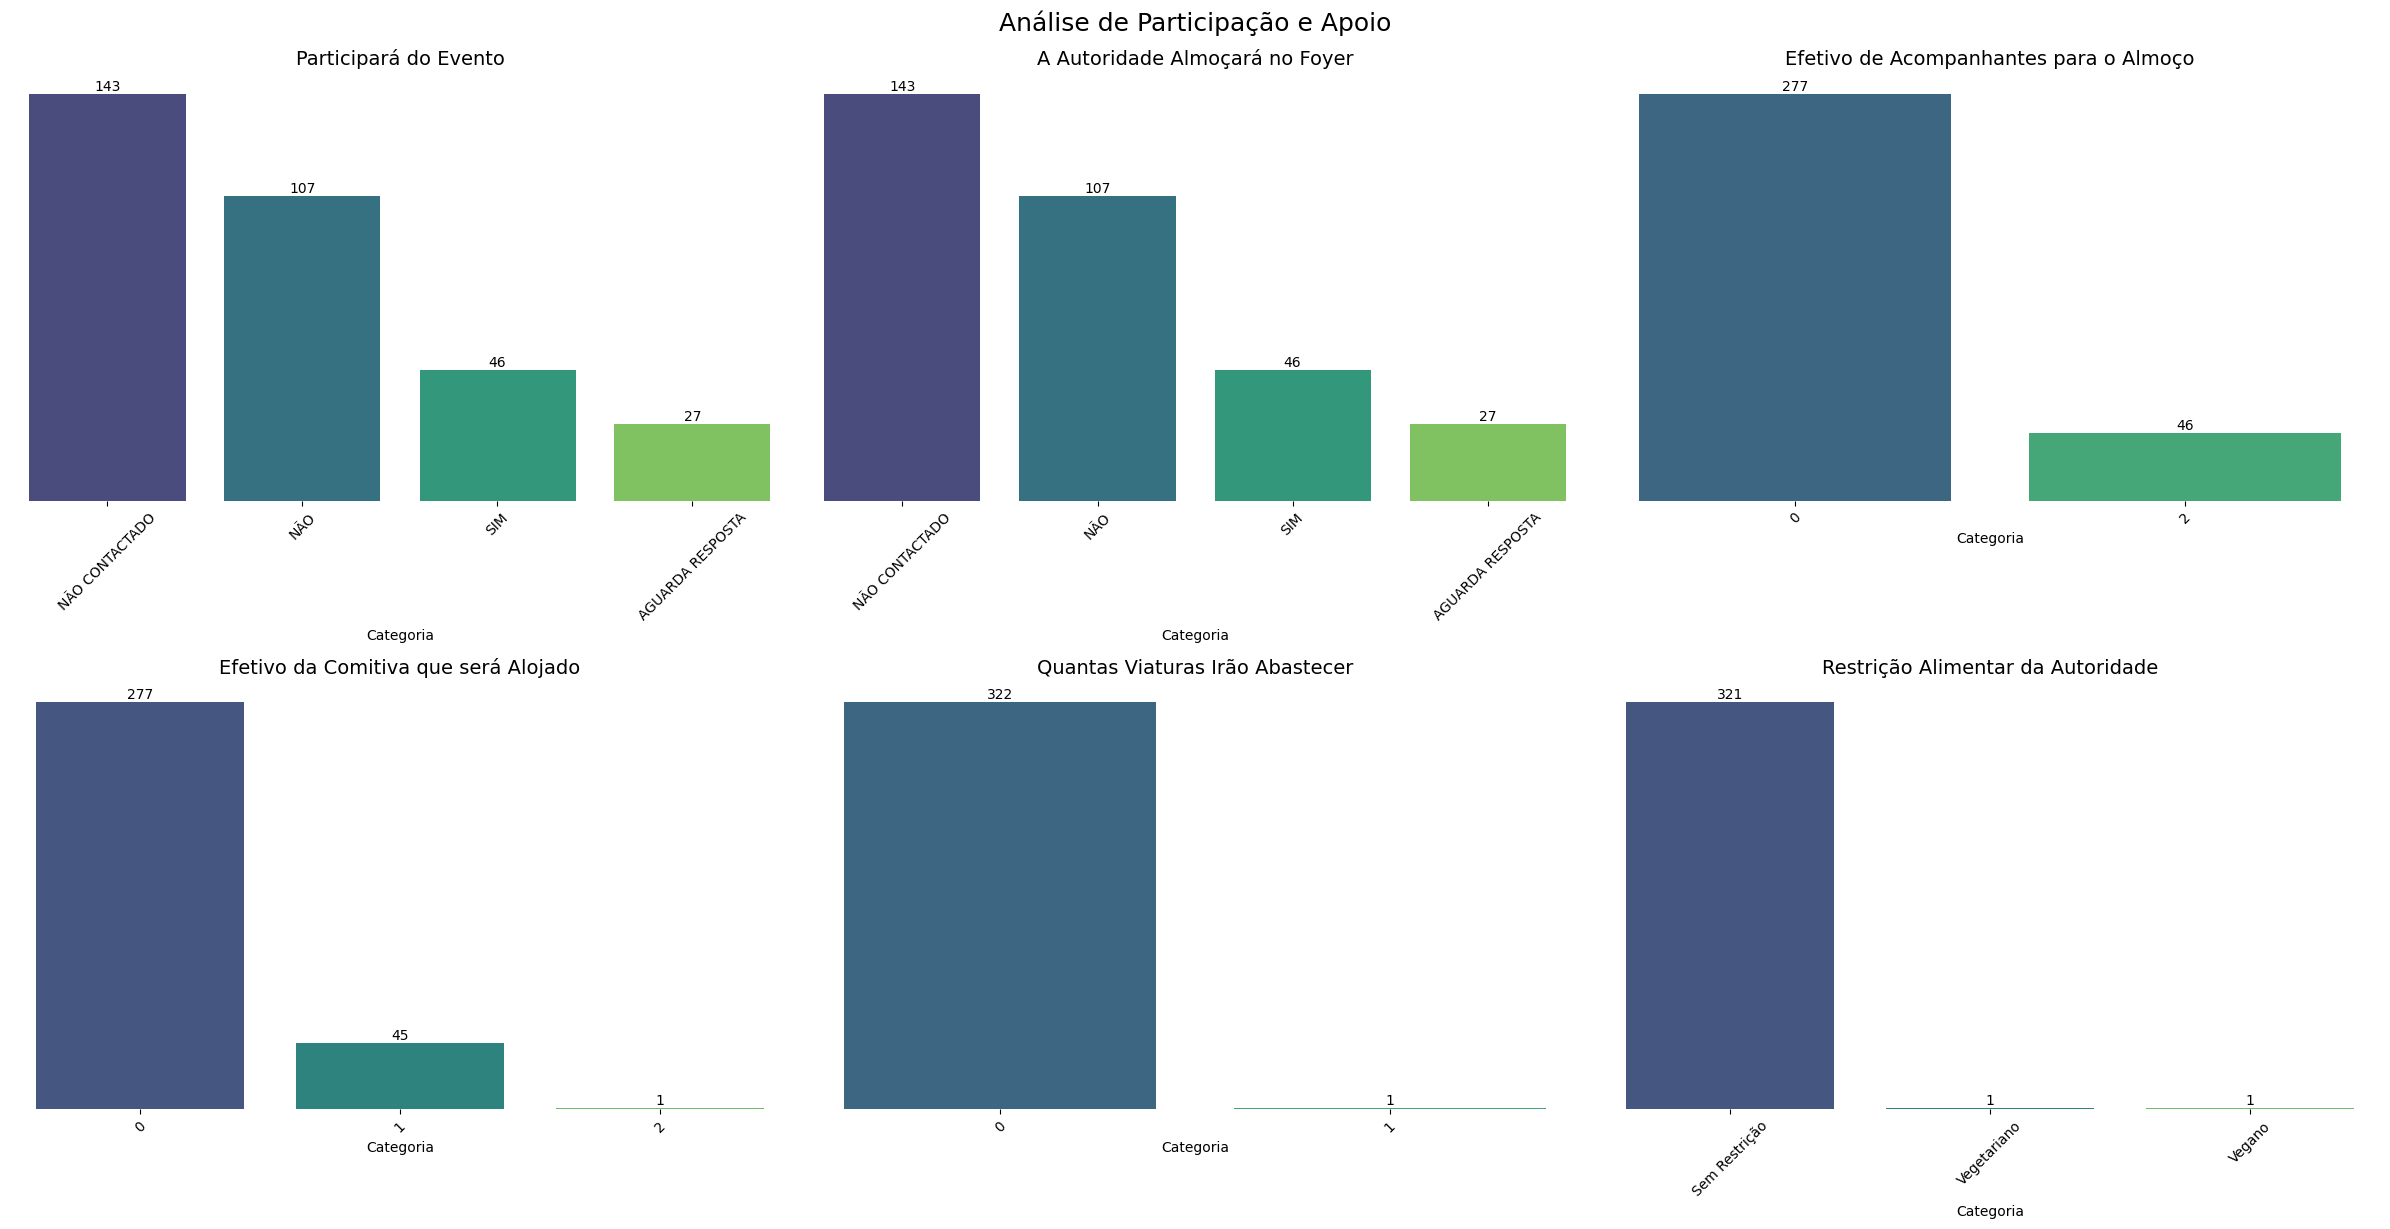

In [ ]:
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

columns_for_stats = [
    'participara_do_evento',
    'a_autoridade_almocara_no_foyer',
    'efetivo_de_acomanhantes_para_o_almoco',
    'efetivo_da_comitiva_que_seja_alojado',

    'quantas_viaturas_irao_abastecer',
    'restricao_alimentar_da_autoridade',

    'participara_da_cerimonia_de_restituicao_dos_espadins',
    'participara_do_culto_religioso',
    'participara_da_entrega_de_premios',
    'participara_da_colacao_de_grau'
]

# Columns for bar charts as requested by the user
bar_chart_columns = [
    'participara_do_evento',
    'a_autoridade_almocara_no_foyer',
    'efetivo_de_acomanhantes_para_o_almoco',
    'efetivo_da_comitiva_que_seja_alojado',
    'quantas_viaturas_irao_abastecer',
    'restricao_alimentar_da_autoridade'
]

# Dictionary for correctly accented titles for the bar charts
bar_chart_titles = {
    'participara_do_evento': 'Participará do Evento',
    'a_autoridade_almocara_no_foyer': 'A Autoridade Almoçará no Foyer',
    'efetivo_de_acomanhantes_para_o_almoco': 'Efetivo de Acompanhantes para o Almoço', # Correcting typo 'acomanhantes' to 'acompanhantes'
    'efetivo_da_comitiva_que_seja_alojado': 'Efetivo da Comitiva que será Alojado',
    'quantas_viaturas_irao_abastecer': 'Quantas Viaturas Irão Abastecer',
    'restricao_alimentar_da_autoridade': 'Restrição Alimentar da Autoridade'
}

# Create a figure and a set of subplots
fig, axes = plt.subplots(2, 3, figsize=(24, 12)) # Changed to 2 rows and 3 columns
axes = axes.flatten() # Flatten the 2x3 array of axes for easy iteration

for i, col in enumerate(bar_chart_columns):
    if col in dados.columns:
        # Get value counts, including NaN values, and convert to DataFrame
        stats_df = dados[col].value_counts(dropna=False).reset_index()
        stats_df.columns = ['Category', 'Count']

        # Handle NaN values explicitly for labels
        stats_df['Category'] = stats_df['Category'].fillna('NaN').astype(str)
        # Replace 'NaN' with 'Sem Restrição' for the specific column
        if col == 'restricao_alimentar_da_autoridade':
            stats_df['Category'] = stats_df['Category'].replace('NaN', 'Sem Restrição')

        # Plot bar chart, explicitly assigning hue to 'Category' and setting legend=False
        sns.barplot(x='Category', y='Count', hue='Category', data=stats_df, ax=axes[i], palette='viridis', legend=False)
        # Use the predefined titles for correct accentuation
        axes[i].set_title(bar_chart_titles.get(col, col.replace("_", " ").title()), fontsize=14)
        axes[i].set_xlabel('Categoria')
        axes[i].set_ylabel('') # Remove y-axis label as requested
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_yticks([]) # Remove y-axis tick numbers

        # Remove the black frame (spines)
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        axes[i].spines['left'].set_visible(False)
        axes[i].spines['bottom'].set_visible(False)

        # Add total counts on top of each bar
        for container in axes[i].containers:
            axes[i].bar_label(container, fmt='%d')

    else:
        axes[i].set_title(f'Coluna: {col.replace("_", " ").title()} - Não encontrada', fontsize=14)
        axes[i].text(0.5, 0.5, 'Dados não disponíveis', horizontalalignment='center', verticalalignment='center', transform=axes[i].transAxes)

# Hide any unused subplots if the number of charts is less than the grid size
for j in range(len(bar_chart_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Análise de Participação e Apoio', y=1.02, fontsize=18)
plt.show()

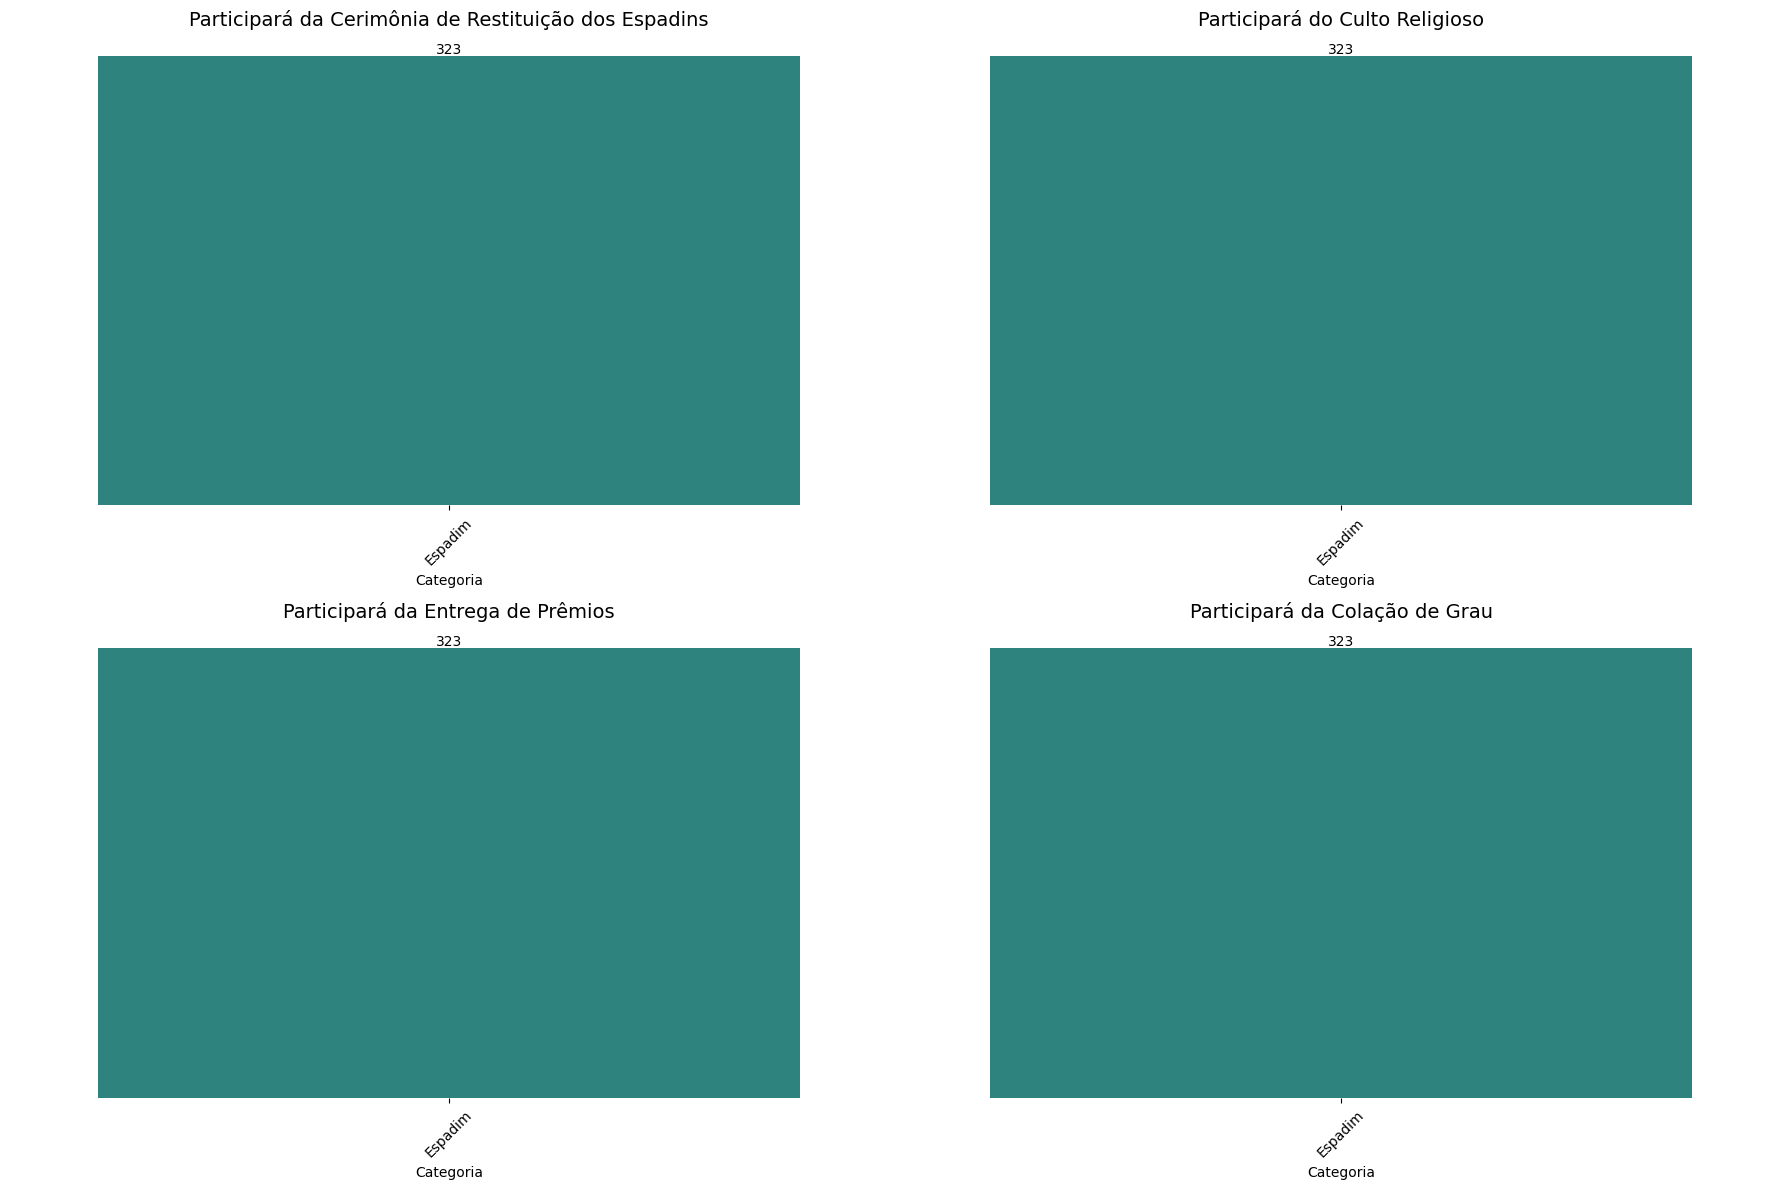

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# New columns for the second set of bar charts
new_bar_chart_columns = [
    'participara_da_cerimonia_de_restituicao_dos_espadins',
    'participara_do_culto_religioso',
    'participara_da_entrega_de_premios',
    'participara_da_colacao_de_grau'
]

# Dictionary for correctly accented titles for the new bar charts
new_bar_chart_titles = {
    'participara_da_cerimonia_de_restituicao_dos_espadins': 'Participará da Cerimônia de Restituição dos Espadins',
    'participara_do_culto_religioso': 'Participará do Culto Religioso',
    'participara_da_entrega_de_premios': 'Participará da Entrega de Prêmios',
    'participara_da_colacao_de_grau': 'Participará da Colação de Grau'
}

# Create a new figure and a set of subplots for the new charts (2 rows, 2 columns)
fig2, axes2 = plt.subplots(2, 2, figsize=(18, 12))
axes2 = axes2.flatten() # Flatten the 2x2 array of axes for easy iteration

for i, col in enumerate(new_bar_chart_columns):
    if col in dados.columns:
        # Get value counts, including NaN values, and convert to DataFrame
        stats_df = dados[col].value_counts(dropna=False).reset_index()
        stats_df.columns = ['Category', 'Count']

        # Handle NaN values explicitly for labels
        stats_df['Category'] = stats_df['Category'].fillna('NaN').astype(str)

        # Plot bar chart, explicitly assigning hue to 'Category' and setting legend=False
        sns.barplot(x='Category', y='Count', hue='Category', data=stats_df, ax=axes2[i], palette='viridis', legend=False)
        # Use the predefined titles for correct accentuation
        axes2[i].set_title(new_bar_chart_titles.get(col, col.replace("_", " ").title()), fontsize=14)
        axes2[i].set_xlabel('Categoria')
        axes2[i].set_ylabel('') # Remove y-axis label as requested
        axes2[i].tick_params(axis='x', rotation=45)
        axes2[i].set_yticks([]) # Remove y-axis tick numbers

        # Remove the black frame (spines)
        axes2[i].spines['top'].set_visible(False)
        axes2[i].spines['right'].set_visible(False)
        axes2[i].spines['left'].set_visible(False)
        axes2[i].spines['bottom'].set_visible(False)

        # Add total counts on top of each bar
        for container in axes2[i].containers:
            axes2[i].bar_label(container, fmt='%d')

    else:
        axes2[i].set_title(f'Coluna: {col.replace("_", " ").title()} - Não encontrada', fontsize=14)
        axes2[i].text(0.5, 0.5, 'Dados não disponíveis', horizontalalignment='center', verticalalignment='center', transform=axes2[i].transAxes)

# Hide any unused subplots if the number of charts is less than the grid size
for j in range(len(new_bar_chart_columns), len(axes2)):
    fig2.delaxes(axes2[j])

plt.tight_layout()
plt.show()